# EDA on the final sub dataframe

In [1]:
# import necessary libraries
##
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
sns.set_palette('bright')
sns.set_context('notebook')

In [2]:
df = pd.read_csv("csv files/final_subdf.csv", parse_dates=['Date'])

In [3]:
df.head(3)

,Date,HomeTeam,AwayTeam,HomeTeam_n,AwayTeam_n,FTHG,FTAG,B365H,B365D,B365A
0,2010-08-14,Aston Villa,West Ham,25.0,11.0,3.0,0.0,2.00,3.30,4.0
1,2010-08-14,Blackburn,Everton,33.0,14.0,1.0,0.0,2.88,3.25,2.5
2,2010-08-14,Bolton,Fulham,3.0,29.0,0.0,0.0,2.20,3.30,3.4


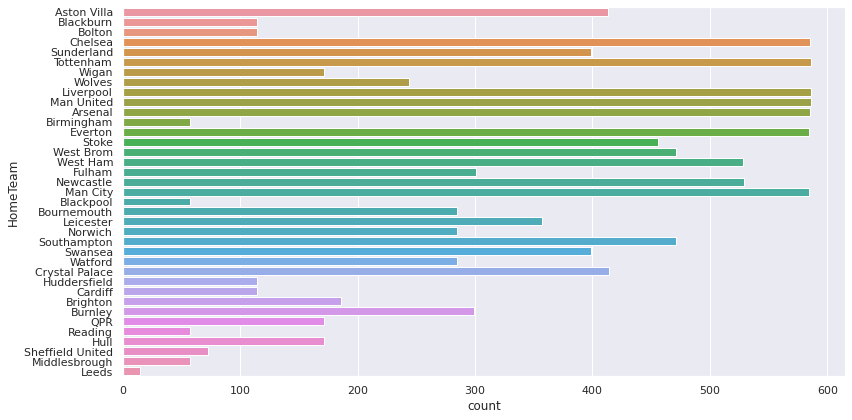

In [4]:
# A plot of how much the teams played from home
##
plt.figure(figsize=(12,6))
sns.countplot(y='HomeTeam', data=df)
plt.tight_layout()

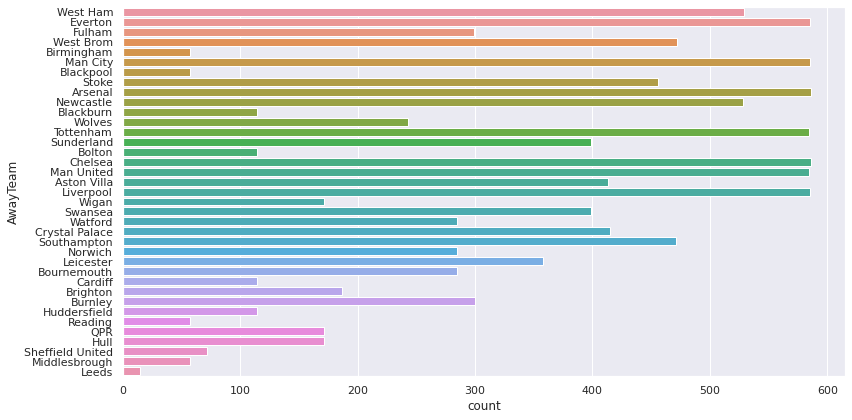

In [5]:
# A plot of how much the teams played from away
##
plt.figure(figsize=(12,6))
sns.countplot(y='AwayTeam', data=df)
plt.tight_layout()

In [6]:
# new column 'result' to show home-win, draw or away-win
##
df['result'] = np.nan

for i, team in enumerate(df.HomeTeam):
    if df.loc[i, 'FTHG'] > df.loc[i, 'FTAG']:
        df.loc[i, 'result'] = 'Home Win'
    elif df.loc[i, 'FTHG'] == df.loc[i, 'FTAG']:
        df.loc[i, 'result'] = 'Draw'
    elif df.loc[i, 'FTHG'] < df.loc[i, 'FTAG']:
        df.loc[i, 'result'] = 'Away Win'
    else:
        pass

In [7]:
df.head()

,Date,HomeTeam,AwayTeam,HomeTeam_n,AwayTeam_n,FTHG,FTAG,B365H,B365D,B365A,result
0,2010-08-14,Aston Villa,West Ham,25.0,11.0,3.0,0.0,2.00,3.30,4.0,Home Win
1,2010-08-14,Blackburn,Everton,33.0,14.0,1.0,0.0,2.88,3.25,2.5,Home Win
2,2010-08-14,Bolton,Fulham,3.0,29.0,0.0,0.0,2.20,3.30,3.4,Draw
3,2010-08-14,Chelsea,West Brom,31.0,21.0,6.0,0.0,1.17,7.00,17.0,Home Win
4,2010-08-14,Sunderland,Birmingham,5.0,20.0,2.0,2.0,2.10,3.30,3.6,Draw


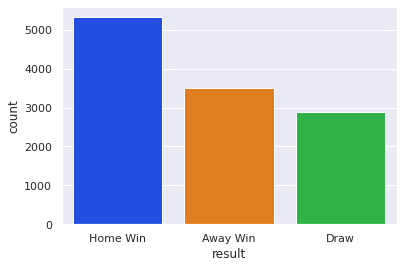

In [8]:
# distribution of results
##
sns.countplot('result', data=df, order=['Home Win', 'Away Win', 'Draw'])

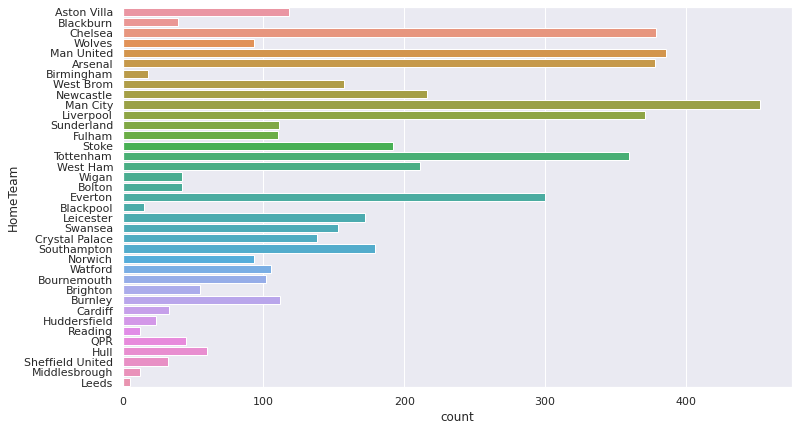

In [9]:
# plot to show home wins for every team
##
plt.figure(figsize=(12,7))
sns.countplot(y='HomeTeam',data=df[df.result == 'Home Win'])

Man City has the most Home Wins  
Leeds has the least

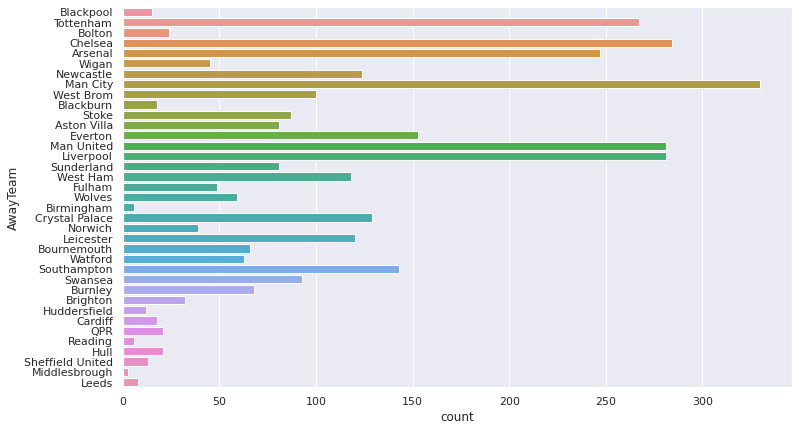

In [10]:
# plot to show Away wins for every team
##
plt.figure(figsize=(12,7))
sns.countplot(y='AwayTeam',data=df[df.result == 'Away Win'])

Man City has the most Away Wins  
Middlesbrough has the least  

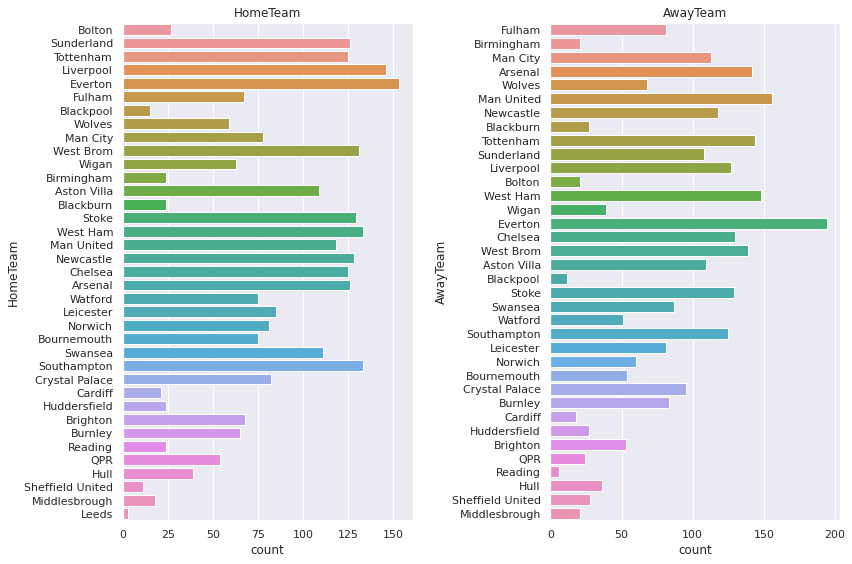

In [11]:
# plot to show draws
##
fig, ax = plt.subplots(1, 2, figsize=(12,8))
sns.countplot(y='HomeTeam', data=df[df.result == 'Draw'], ax=ax[0])
ax[0].set_title("HomeTeam")
sns.countplot(y='AwayTeam', data=df[df.result == 'Draw'], ax=ax[1])
ax[1].set_title("AwayTeam")

plt.tight_layout()

Everton has most Draws from Home  
Leeds has the least  

Everton also has the most Draws from Away  
Reading has the least



In [12]:
# preview which teams the above teams(esp. Everton) have Drawn with
##
df[(df.HomeTeam == 'Everton') & (df.result == 'Draw')]

,Date,HomeTeam,AwayTeam,HomeTeam_n,AwayTeam_n,FTHG,FTAG,B365H,B365D,B365A,result
12,2010-08-21,Everton,Wolves,14.0,17.0,1.0,1.0,1.50,4.00,7.00,Draw
31,2010-11-09,Everton,Man United,14.0,1.0,3.0,3.0,4.20,3.40,1.91,Draw
114,2010-10-11,Everton,Bolton,14.0,3.0,1.0,1.0,1.62,3.75,6.00,Draw
160,2010-11-12,Everton,Wigan,14.0,18.0,0.0,0.0,1.40,4.50,9.00,Draw
224,2011-01-22,Everton,West Ham,14.0,11.0,2.0,2.0,1.50,4.00,7.50,Draw
...,...,...,...,...,...,...,...,...,...,...,...
11461,2014-03-12,Everton,Hull,14.0,26.0,1.0,1.0,1.53,4.33,7.00,Draw
11526,2015-10-01,Everton,Man City,14.0,34.0,1.0,1.0,4.50,3.75,1.85,Draw
11542,2015-01-19,Everton,West Brom,14.0,21.0,0.0,0.0,1.85,3.60,4.75,Draw
11554,2015-07-02,Everton,Liverpool,14.0,30.0,0.0,0.0,3.40,3.40,2.30,Draw


Text(0.5, 1.0, 'Teams that did Draw with Everton(Home)')

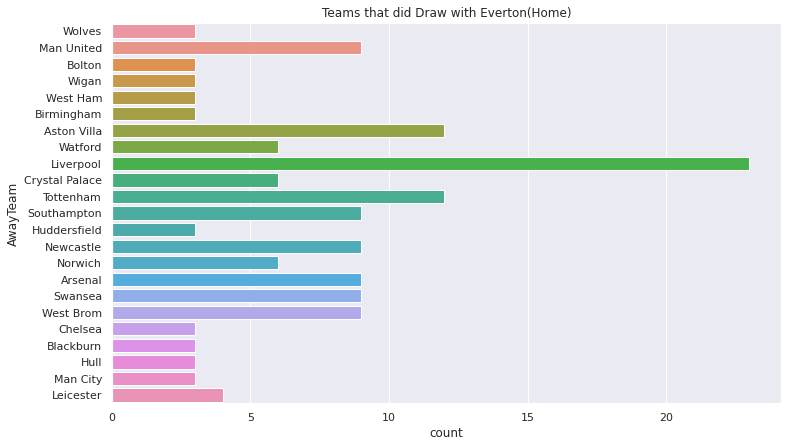

In [13]:
plt.figure(figsize=(12,7))
sns.countplot(y='AwayTeam', data=df[(df.HomeTeam == 'Everton') & (df.result == 'Draw')])
plt.title("Teams that did Draw with Everton(Home)")

Liverpool did Draw the most with Everton while Everton was the Home Team


Text(0.5, 1.0, 'Teams that did Draw with Everton(Away)')

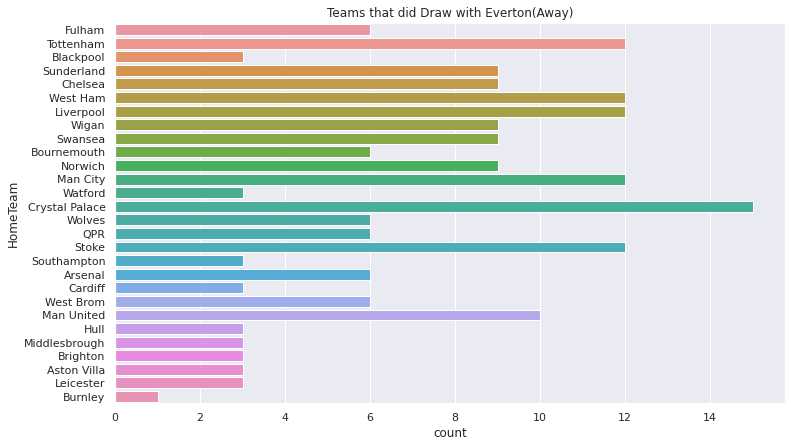

In [14]:
plt.figure(figsize=(12,7))
sns.countplot(y='HomeTeam', data=df[(df.AwayTeam == 'Everton') & (df.result == 'Draw')])
plt.title("Teams that did Draw with Everton(Away)")

Crystal Palace did Draw the most with Everton while Everton was the Away Team

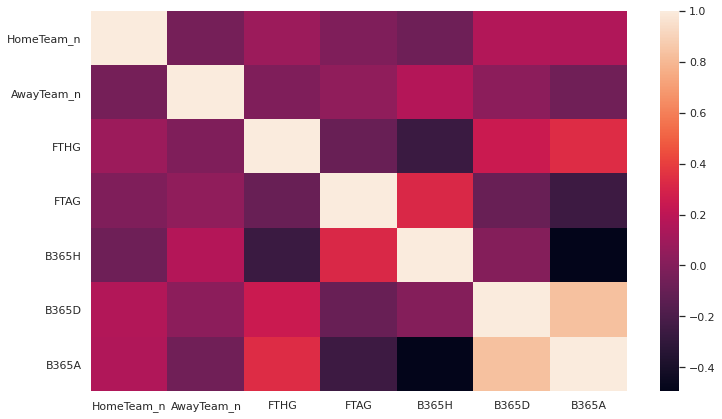

In [15]:
# heatmap
##
plt.figure(figsize=(12,7))
sns.heatmap(df.corr())

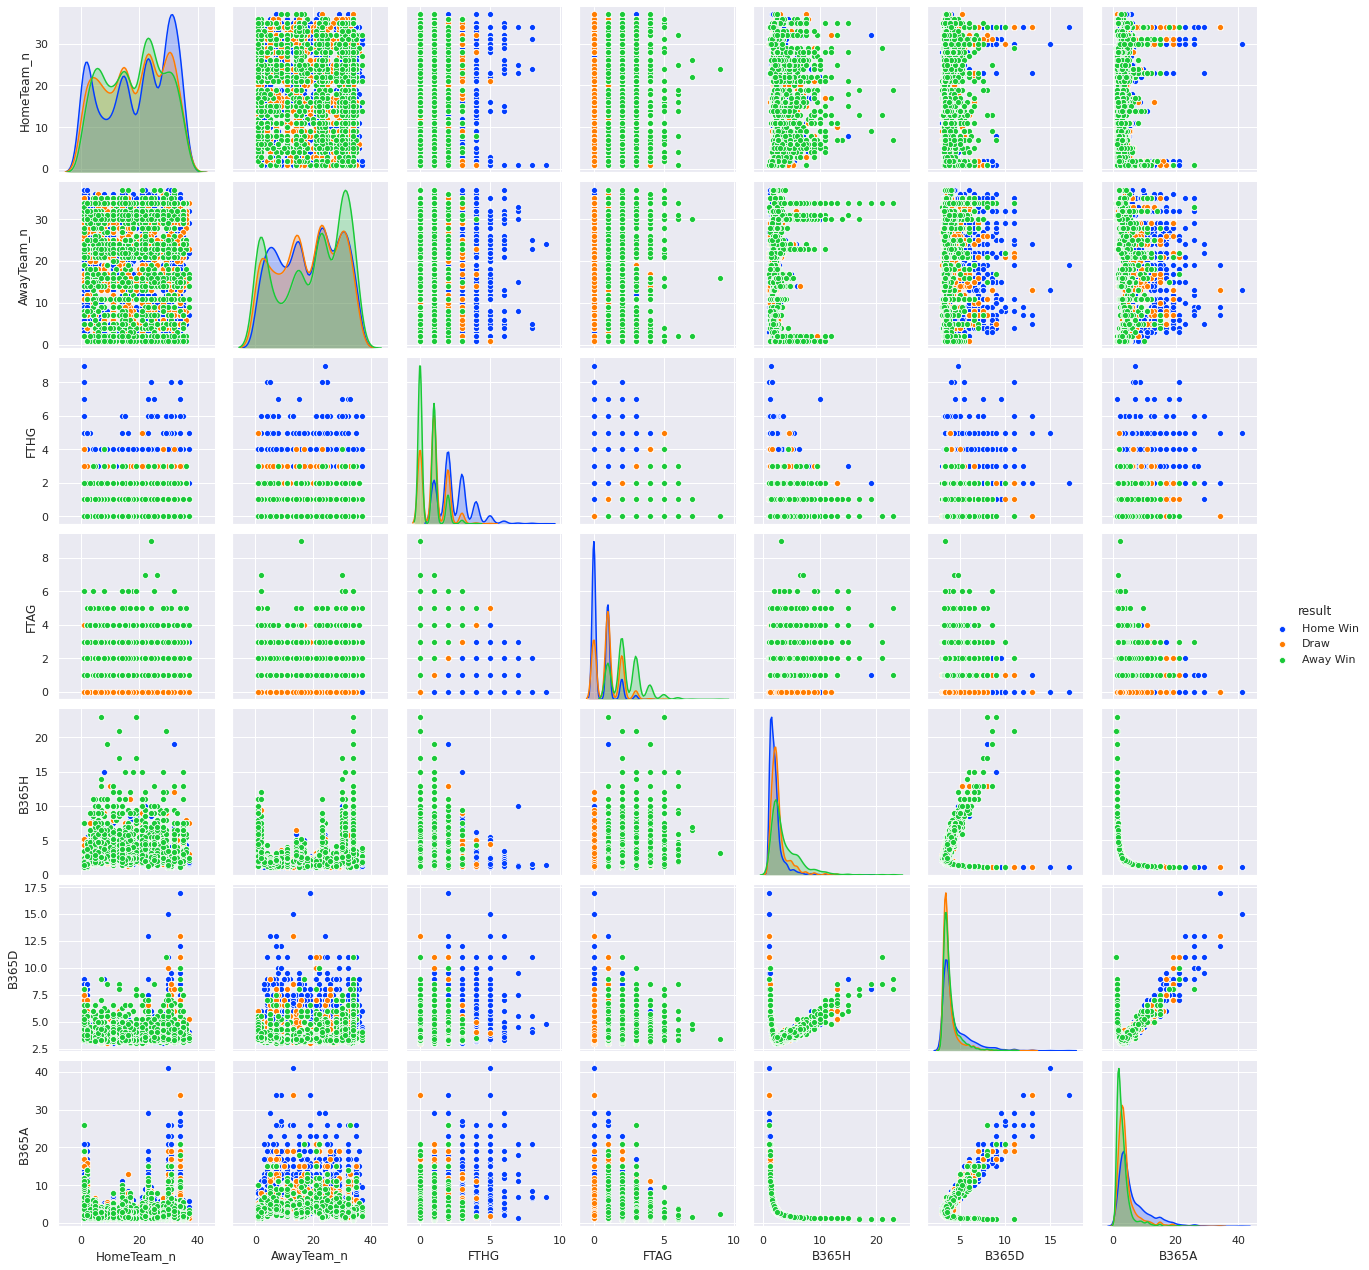

In [16]:
# pairplot
##
sns.pairplot(df, hue='result')

In [17]:
df.head()

,Date,HomeTeam,AwayTeam,HomeTeam_n,AwayTeam_n,FTHG,FTAG,B365H,B365D,B365A,result
0,2010-08-14,Aston Villa,West Ham,25.0,11.0,3.0,0.0,2.00,3.30,4.0,Home Win
1,2010-08-14,Blackburn,Everton,33.0,14.0,1.0,0.0,2.88,3.25,2.5,Home Win
2,2010-08-14,Bolton,Fulham,3.0,29.0,0.0,0.0,2.20,3.30,3.4,Draw
3,2010-08-14,Chelsea,West Brom,31.0,21.0,6.0,0.0,1.17,7.00,17.0,Home Win
4,2010-08-14,Sunderland,Birmingham,5.0,20.0,2.0,2.0,2.10,3.30,3.6,Draw


In [18]:
# the last dataframe for use in modeling
##
last_df = df[['Date', 'HomeTeam', 'AwayTeam', 'HomeTeam_n', 'AwayTeam_n', 'B365H', 'B365D', 'B365A', 'result']]

In [19]:
# sort by date
##
last_df = last_df.sort_values('Date')

last_df.reset_index(drop=True, inplace=True)

In [20]:
last_df.to_csv("csv files/lastdf.csv", index=False)